# Predicting Unsafe Air Quality (AQI)

### Using Environmental, Weather, and Demographic Data

**Project by:**  
Bhavna Sreekumar · Sarkis Shil-Gevorkyan · Christopher Strouse

---

## Project Resources

- Bhavna GitHub Repository: [Github](https://github.com/bhavnasreekumar/BSAN6070-Final-Project)
- Sarkis GitHub Repository:[GitHub](https://github.com/Sarkis55/Air_Quality_Predictor)
- Chris GitHub Repository: [GitHub](https://github.com/ckstrouse/-Predicting-Unsafe-Air-Quality-AQI-.git)
- Streamlit Deployment: [Streamlit](https://air-quality-predictor2-u8wqtkam3tbrbxabvb9weq.streamlit.app/)
- Google Drive with All Datasets Used: [Datasets](https://drive.google.com/drive/folders/1ynkHP16cOvcZ6zCXRGuHYju9hGEbfB7I?usp=drive_link)

## **Project** **Objective** **&** **Predictive** **Question**

This project examines whether environmental, weather, and demographic data can be used to predict unsafe air quality conditions in California counties.

**The primary goal** was to classify whether a given day would experience elevated AQI levels using historical ozone, weather, seasonal, and population-related variables.

**A secondary objective** was to identify which variables contributed most strongly to unsafe AQI predictions and compare how different machine learning models performed under class imbalance conditions.

## **Literature Survey**

Previous research has shown that machine learning techniques can effectively model and predict air quality conditions using environmental and meteorological variables.

Studies such as Zhang et al. (2012) and Li et al. (2017) demonstrated that weather-related variables including temperature, wind speed, and precipitation significantly influence pollutant concentration and AQI variability. These findings established that meteorological conditions play a major role in pollutant formation, dispersion, and seasonal AQI variation.

More recent studies have applied ensemble machine learning techniques to AQI prediction tasks using pollutant, weather, and demographic variables. A 2025 study in PLOS ONE benchmarked Logistic Regression, Random Forest, and XGBoost on AQI forecasting and found that Random Forest achieved the lowest prediction error while XGBoost explained the greatest proportion of AQI variance. SHAP analysis within the study identified PM2.5, NOx, and CO as dominant predictors influencing model performance (Taşağıl-Arslan et al.).

A separate comparative study published in Stochastic Environmental Research and Risk Assessment evaluated multiple machine learning models across diverse air quality datasets and found that gradient-boosted ensemble methods consistently outperformed traditional linear approaches. The study attributed this performance advantage to tree-based models’ ability to capture nonlinear interactions among pollutant and meteorological variables without requiring strict statistical assumptions.

Research by Jiang et al. (2021) similarly found that tree-based ensemble models frequently outperform traditional statistical forecasting methods in AQI prediction because of their ability to model complex environmental interactions. Logistic Regression nevertheless remains widely used as a baseline classification model because of its interpretability and relatively simple probabilistic structure.

Several prior AQI prediction studies relied heavily on pollutant concentration variables such as PM2.5 and PM10 as predictors. However, because PM2.5 directly contributes to AQI calculations, its inclusion can introduce target leakage and artificially inflate predictive performance. This project addressed that limitation by removing PM2.5 from the final predictor set so that the models relied on independent environmental, weather, seasonal, and demographic variables instead.

Existing literature also identifies class imbalance as a major challenge in environmental risk prediction problems because unsafe AQI observations occur relatively infrequently. Chawla et al. (2002), in their foundational work on SMOTE and imbalanced classification, demonstrated that rare-event datasets require specialized handling strategies beyond standard accuracy optimization. Subsequent research on environmental classification problems similarly recommends the use of balanced class weights, recall-focused evaluation metrics, and AUC-based model evaluation when predicting infrequent high-risk events.

Consistent with these findings, this project emphasized Class 1 recall and AUC rather than relying solely on overall accuracy. Balanced class weighting was incorporated into Logistic Regression and Random Forest models to improve identification of unsafe AQI observations under severe class imbalance conditions.

Our project differs from prior work by combining ozone, weather, seasonal, and demographic variables into a county-level AQI classification framework focused specifically on California environmental conditions. In addition to comparing multiple machine learning algorithms, the project also emphasized interpretability through feature importance analysis and SHAP interpretation.

#### References

- Zhang, Y., Bocquet, M., Mallet, V., Seigneur, C., & Baklanov, A. (2012). Real-time air quality forecasting, part I: History, techniques, and current status.

- Li, X., Peng, L., Hu, Y., Shao, J., & Chi, T. (2017). Deep learning architecture for air quality predictions.

- Jiang, D., Zhang, Y., Hu, X., Zeng, Y., Tan, J., & Shao, D. (2021). Progress in developing ensemble machine learning models for air pollution prediction.

- Breiman, L. (2001). Random Forests. Machine Learning.

- Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system.

- Taşağıl-Arslan, S. (2025). Machine Learning-Based Forecasting of Air Quality Index under Long-Term Environmental Patterns. PLOS ONE. https://pmc.ncbi.nlm.nih.gov/articles/PMC12507303/

- Taşağıl-Arslan, S., et al. (2026). Interpretable Machine Learning Framework for Air Quality Prediction in Istanbul Using SHAP. Stochastic Environmental Research and Risk Assessment. https://link.springer.com/article/10.1007/s00477-026-03168-4

- Aguilera, R., et al. (2025). Effects of Multiple Wildfire Smoke Pollutants on Respiratory and Cardiovascular Hospitalizations in California. GeoHealth. https://pmc.ncbi.nlm.nih.gov/articles/PMC12712234/

- Abdelhamid, M., & Desai, A. (2024). Balancing the Scales: A Comprehensive Study on Tackling Class Imbalance in Binary Classification. arXiv. https://arxiv.org/abs/2409.19751

- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. Journal of Artificial Intelligence Research.

## **Domain** **Understanding** **Reflection**

Air quality is measured using the Air Quality Index (AQI), a standardized scale developed by the United States Environmental Protection Agency (EPA) that translates pollutant concentrations into a single numerical value representing public health risk. AQI is influenced by several pollutants including ozone, PM2.5, PM10, carbon monoxide, sulfur dioxide, and nitrogen dioxide, with ozone and PM2.5 serving as major contributors in many California regions.

California presents a uniquely complex environmental setting for AQI prediction due to dense urban populations, heavy transportation activity, agricultural emissions, seasonal wildfire smoke, and prolonged warm-weather conditions. Ozone formation is strongly influenced by heat and sunlight, while wildfire activity can sharply increase particulate pollution levels. These environmental patterns help explain why variables such as temperature, precipitation, seasonality, and ozone concentration were expected to carry predictive value within the modeling framework.

This project framed AQI prediction as a binary classification problem because public health decisions are often based on whether AQI crosses a risk threshold rather than on the exact AQI value itself. An AQI threshold of 100 was selected to represent unhealthy air quality conditions for sensitive populations and to align more closely with EPA health risk categories.

A key methodological consideration involved avoiding target leakage by ensuring that predictors remained independent from AQI calculation components.

## **Descriptive Statistics and Data Quality Analysis**

The project combined California county-level ozone, AQI, weather, and population datasets from multiple public data sources covering multiple years of observations. Raw environmental datasets initially contained missing values, duplicate records, inconsistent formatting, and highly granular monitoring station observations.

To prepare the data for predictive modeling, the datasets were aggregated to the county-date level so that each row represented a single county observation for a specific day. Data cleaning steps included removing duplicate records, handling missing values, converting date fields into datetime format, standardizing variable formats, and merging datasets using common county and date fields.

Feature engineering was also performed to improve model interpretability and predictive capability. Additional variables such as temperature range, rainy-day indicators, seasonal categories, and weekend indicators were created from the original weather and date fields.

Outlier filtering was applied to reduce the influence of extreme environmental measurements that could distort model performance. Class imbalance was also identified as an important issue because unsafe AQI observations represented a relatively small percentage of the total dataset. For this reason, evaluation metrics such as AUC, recall, and F1-score were emphasized in addition to accuracy.

Final descriptive statistics and feature distributions were reviewed using summary statistics, correlation analysis, and visualization techniques prior to model development.

## Data Sources

The project integrated multiple public datasets related to air quality, weather, and demographics:

- EPA Outdoor Air Quality Data (AQI, Ozone)
- NOAA Climate and Weather Data
- U.S. Census Population Data

Source Links:
- EPA: https://www.epa.gov/outdoor-air-quality-data/download-daily-data
- NOAA: https://www.ncei.noaa.gov/cdo-web/search
- Census: https://data.census.gov/

In [1]:
# ==========================================
# LOAD AND COMBINE AIR QUALITY DATA
# ==========================================

# NOTE:
# Before running, make sure to:
# 1. Open the dataset folder link from README
# 2. Click "Add shortcut to Drive"
# 3. Ensure folder is in "My Drive" and named "project datasets"

# Mount Google Drive so the dataset files can be accessed in Colab.
from google.colab import drive
drive.mount('/content/drive')

# Import required libraries

import pandas as pd
import glob

# Path to the folder in Google Drive with all the datasets
folder_path = "/content/drive/MyDrive/project datasets/"


# Load PM2.5 and ozone CSV files from Google Drive and combine yearly files into one dataframe.
pm25_files = glob.glob(folder_path + "ad_viz_plotval_data*.csv")

pm25_df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in pm25_files],
    ignore_index=True
)

ozone_files = glob.glob(folder_path + "ozone_*.csv")

ozone_df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in ozone_files],
    ignore_index=True
)

print("PM2.5 shape:", pm25_df.shape)
print("Ozone shape:", ozone_df.shape)

print(pm25_df.columns)
print(ozone_df.columns)

Mounted at /content/drive
PM2.5 shape: (292465, 22)
Ozone shape: (269253, 21)
Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')
Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')


In [2]:
# Rename key columns and convert date fields into datetime format for merging and feature engineering.

ozone_df = ozone_df.rename(columns={
    'Date Local': 'Date',
    'Daily Max 8-hour Ozone Concentration': 'Ozone'
})

ozone_df['Date'] = pd.to_datetime(ozone_df['Date'], errors='coerce')
pm25_df['Date'] = pd.to_datetime(pm25_df['Date'], errors='coerce')

# Drop rows where dates failed
ozone_df = ozone_df.dropna(subset=['Date'])
pm25_df = pm25_df.dropna(subset=['Date'])

In [3]:
# Aggregate PM2.5 and ozone data to the county-day level.

# Average PM2.5 by Date + County
pm25_daily = pm25_df.groupby(['Date', 'County'], as_index=False).agg({
    'Daily AQI Value': 'mean',
    'Daily Mean PM2.5 Concentration': 'mean',
    'Site Latitude': 'mean',
    'Site Longitude': 'mean'
})

pm25_daily = pm25_daily.rename(columns={
    'Daily AQI Value': 'AQI',
    'Daily Mean PM2.5 Concentration': 'PM25',
    'Site Latitude': 'Latitude',
    'Site Longitude': 'Longitude'
})

# Average ozone by Date + County
ozone_daily = ozone_df.groupby(['Date', 'County'], as_index=False).agg({
    'Ozone': 'mean'
})

# Merge PM2.5 and ozone datasets by Date and County to create the main air quality dataset.
df = pm25_daily.merge(
    ozone_daily,
    on=['Date', 'County'],
    how='inner'
)

print(df.shape)
df[['Date', 'County', 'PM25', 'Ozone', 'AQI']].head()

(74366, 7)


,Date,County,PM25,Ozone,AQI
0,2021-01-01,Alameda,17.283333,0.0224,66.166667
1,2021-01-01,Butte,14.933333,0.0255,58.000000
2,2021-01-01,Calaveras,11.000000,0.0280,55.000000
3,2021-01-01,Colusa,15.200000,0.0150,62.000000
4,2021-01-01,Contra Costa,11.333333,0.0215,55.000000


## **Target Leakage Correction**

PM2.5 was initially included as a predictor variable. However, because PM2.5 directly contributes to AQI calculations, it introduced target leakage and artificially inflated model performance.

To improve methodological validity, PM2.5 was removed from the final predictive models.

In [4]:
# Remove PM2.5 to avoid target leakage
# PM2.5 is directly tied to AQI calculation, so it should not be used as a predictor.
if 'PM25' in df.columns:
    df = df.drop(columns=['PM25'])

In [5]:
df.columns

Index(['Date', 'County', 'AQI', 'Latitude', 'Longitude', 'Ozone'], dtype='object')

In [6]:
df = df[['Date', 'County', 'Ozone', 'AQI', 'Latitude', 'Longitude']]

In [7]:
df = df.sort_values(by=['County', 'Date'])

In [8]:
df = df.reset_index(drop=True)

In [9]:
# Check for missing values before modeling.
df.isnull().sum()

,0
Date,0
County,0
Ozone,0
AQI,0
Latitude,0
Longitude,0


In [10]:
# Check for duplicate records before modeling.
df.duplicated(subset=['Date', 'County']).sum()

np.int64(0)

In [11]:
# Remove invalid AQI values only
df = df[df['AQI'] >= 0]

In [12]:
df.describe()

,Date,Ozone,AQI,Latitude,Longitude
count,74366,74366.000000,74366.000000,74366.000000,74366.000000
mean,2023-06-12 09:53:20.527122688,0.040665,37.181515,37.227312,-120.595834
min,2021-01-01 00:00:00,0.002000,0.000000,32.676180,-124.179490
25%,2022-03-10 00:00:00,0.032500,23.000000,36.208957,-122.136373
50%,2023-05-19 00:00:00,0.039500,35.500000,37.565241,-121.055608
75%,2024-09-25 00:00:00,0.048000,49.571429,38.924800,-119.587094
max,2025-12-31 00:00:00,0.096778,745.000000,41.726892,-115.483070
std,NaN,0.012538,20.045721,2.140747,1.886630


In [13]:
df.head()
df['Date'].head()

,Date
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05


In [14]:
# # Create the target variable: 1 = unsafe/unhealthy AQI, 0 = safe AQI.

df['AQI_Category'] = (df['AQI'] >= 100).astype(int)

df['AQI_Category'].value_counts(normalize=True)

,proportion
AQI_Category,
0,0.991717
1,0.008283


In [15]:
# Feature Engineering: Engineer date-based features such as year, month, weekday, weekend indicator, and season.

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


# Day of week (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Weekend indicator
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Season (VERY important for pollution patterns)
def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Fall


# Categorical features such as season were one-hot encoded for tree-based models.

df['Season'] = df['Month'].apply(get_season)

Categorical seasonal variables were one-hot encoded to ensure compatibility across machine learning models and avoid imposing ordinal relationships between seasons.

In [16]:
df.isnull().sum()

,0
Date,0
County,0
Ozone,0
AQI,0
Latitude,0
Longitude,0
AQI_Category,0
Year,0
Month,0
DayOfWeek,0


## External Data Overlay and Dataset Integration

The project integrated multiple public datasets from environmental, weather, and demographic sources. AQI and ozone observations were obtained from the United States Environmental Protection Agency (EPA) Outdoor Air Quality Data repository. Weather-related variables including temperature, precipitation, and wind speed were collected from NOAA climate and weather datasets. County-level population information was incorporated from publicly available census-based demographic data sources. These datasets were combined to create a unified county-level environmental prediction dataset for California.

We combined and overlaid multiple external datasets to build a comprehensive county-level air quality prediction framework for California. Air quality observations including AQI and ozone measurements were merged with weather-related variables and county-level population data to better capture environmental and demographic influences on unsafe AQI conditions.


Having EPA, NOAA, and Census datasets made it possible to analyze AQI conditions using both environmental and demographic context rather than pollutant measurements alone. This helped the project move beyond simple pollutant prediction by incorporating contextual variables such as temperature, precipitation, wind speed, seasonal patterns, and population exposure. Combining these independent data sources improved the overall richness of the feature space and provided a more realistic representation of the factors influencing air quality outcomes.

Because the datasets originated from different public sources and granularities, extensive preprocessing and alignment were required. Data was standardized, aggregated to the county-date level, and merged using common temporal and geographic identifiers. This external data overlay process strengthened the predictive modeling framework and supported a more comprehensive environmental analysis.

In [17]:
# Load and clean county population data, then merge it into the main dataset as a demographic feature.

pop_df = pd.read_csv('/content/drive/MyDrive/project datasets/population.csv')

In [18]:
pop_df.head()
pop_df.columns

Index(['Label (Grouping)', 'California!!Estimate',
       'California!!Margin of Error', 'California!!Percent',
       'California!!Percent Margin of Error',
       'Alameda County, California!!Estimate',
       'Alameda County, California!!Margin of Error',
       'Alameda County, California!!Percent',
       'Alameda County, California!!Percent Margin of Error',
       'Alpine County, California!!Estimate',
       ...
       'Ventura County, California!!Percent',
       'Ventura County, California!!Percent Margin of Error',
       'Yolo County, California!!Estimate',
       'Yolo County, California!!Margin of Error',
       'Yolo County, California!!Percent',
       'Yolo County, California!!Percent Margin of Error',
       'Yuba County, California!!Estimate',
       'Yuba County, California!!Margin of Error',
       'Yuba County, California!!Percent',
       'Yuba County, California!!Percent Margin of Error'],
      dtype='object', length=237)

In [19]:
# Get only columns with "Estimate"
estimate_cols = [col for col in pop_df.columns if 'Estimate' in col]

In [20]:
pop_clean = pop_df[estimate_cols].copy()

In [21]:
# Keep only estimate columns
estimate_cols = [col for col in pop_df.columns if 'Estimate' in col]

pop_clean = pop_df[estimate_cols].copy()

# Rename columns to county names
pop_clean.columns = [
    col.split(' County')[0].replace(', California', '')
    for col in pop_clean.columns
]

# Find the row that actually has population values (not headers)

pop_clean = pop_clean.loc[pop_clean.notna().any(axis=1)].iloc[0]

# Convert to dataframe
pop_clean = pop_clean.reset_index()
pop_clean.columns = ['County', 'Population']

# Clean population values
pop_clean['Population'] = (
    pop_clean['Population']
    .astype(str)
    .str.replace(',', '', regex=False)
)

pop_clean['Population'] = pd.to_numeric(pop_clean['Population'], errors='coerce')

pop_clean = pop_clean.dropna()

pop_clean = pop_clean[pop_clean['County'] != 'California!!Estimate']

In [22]:
pop_clean.head()

,County,Population
1,Alameda,1651949
2,Alpine,1695
3,Amador,41029
4,Butte,209470
5,Calaveras,45995


In [23]:
# Make sure county names match formatting
df['County'] = df['County'].str.strip()
pop_clean['County'] = pop_clean['County'].str.strip()

# Merge population into main dataset
df = df.merge(pop_clean, on='County', how='left')

In [24]:
df[['County', 'Population']].head()
df['Population'].isnull().sum()

np.int64(0)

In [25]:
# Standardize population so features with different scales are more comparable.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Population']] = scaler.fit_transform(df[['Population']])

In [26]:
df[['Population']].describe()

,Population
count,7.436600e+04
mean,1.146561e-17
std,1.000007e+00
min,-5.367280e-01
25%,-4.647151e-01
50%,-3.733413e-01
75%,6.829163e-03
max,5.444982e+00


In [27]:
# Add weather variables and create additional weather features such as temperature range and rainy-day indicator.

weather = pd.read_csv("/content/drive/MyDrive/project datasets/los angeles 2024 weather data.csv")

weather = weather[['DATE', 'PRCP', 'TMAX', 'TMIN', 'AWND']]
weather['DATE'] = pd.to_datetime(weather['DATE'])
weather = weather.ffill().bfill()

df = pd.merge(df, weather, left_on='Date', right_on='DATE', how='left')
df = df.drop(columns=['DATE'])

df['Temp_Range'] = df['TMAX'] - df['TMIN']
df['Is_Rainy'] = (df['PRCP'] > 0).astype(int)

In [28]:
df.columns

Index(['Date', 'County', 'Ozone', 'AQI', 'Latitude', 'Longitude',
       'AQI_Category', 'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'Season',
       'Population', 'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy'],
      dtype='object')

In [29]:
#Define predictor variables and target variable for modeling.

features = [
    'Ozone',
    'Season',
    'IsWeekend',
    'Population',
    'PRCP',
    'TMAX',
    'TMIN',
    'AWND',
    'Temp_Range',
    'Is_Rainy'
]

X = df[features]
y = df['AQI_Category']

In [30]:
df['AQI_Category'].value_counts(normalize=True)

,proportion
AQI_Category,
0,0.991717
1,0.008283


In [31]:
df = df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df['Population'].isnull().sum()

np.int64(0)

In [34]:
# ==========================================
# ENCODE CATEGORICAL VARIABLES (FOR LR + XGB)
# ==========================================

# One-hot encode Season so the model treats seasons as categories
df_encoded = pd.get_dummies(df, columns=['Season'], drop_first=True)

# Define final features
features = [
    col for col in df_encoded.columns
    if col in [
        'Ozone',
        'IsWeekend',
        'Population',
        'PRCP',
        'TMAX',
        'TMIN',
        'AWND',
        'Temp_Range',
        'Is_Rainy'
    ] or 'Season_' in col
]

X = df_encoded[features]
y = df_encoded['AQI_Category']

In [35]:
# Remove rows with missing feature values before training the models.

model_df = df_encoded[features + ['AQI_Category']].dropna()

X = model_df[features]
y = model_df['AQI_Category']

rows, total_cols = model_df.shape
num_features = total_cols - 1

print("Final dataset rows:", rows)
print("Number of model features:", num_features)
print("Features used:", features)

Final dataset rows: 12703
Number of model features: 12
Features used: ['Ozone', 'IsWeekend', 'Population', 'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy', 'Season_2', 'Season_3', 'Season_4']


In [36]:
rows, total_cols = model_df.shape
num_features = total_cols - 1  # remove target column

print(rows, num_features)

12703 12


In [37]:
df['County'].nunique()

47

In [38]:
model_df.shape

(12703, 13)

## **Correlation Analysis**

A correlation heatmap was used to examine relationships between numerical variables and identify highly correlated predictors prior to modeling.

This step helped evaluate potential multicollinearity and feature redundancy within the dataset.

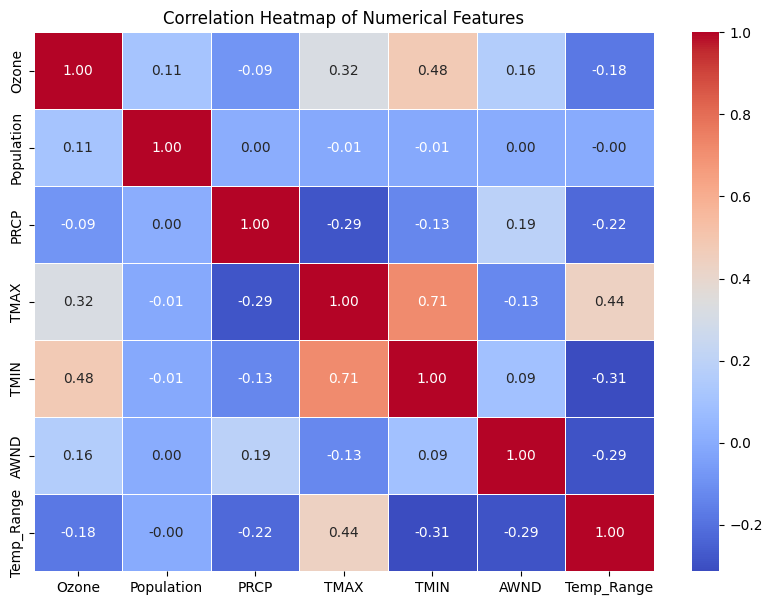

In [39]:
# ============================================
# CORRELATION HEATMAP
# ============================================

# Visualize relationships between numerical features
# to examine potential multicollinearity.

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features for correlation analysis
corr_features = [
    'Ozone',
    'Population',
    'PRCP',
    'TMAX',
    'TMIN',
    'AWND',
    'Temp_Range'
]

# Compute correlation matrix
corr_matrix = df[corr_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Most variables showed only moderate correlation levels, suggesting limited multicollinearity among predictors. Temperature-related variables displayed the strongest relationships, which is expected due to seasonal weather patterns.

In [40]:
df['AQI_Category'].value_counts()

,count
AQI_Category,
0,73750
1,616


In [41]:
# Split the dataset into training and testing sets while preserving the class distribution.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
X.isnull().sum()

,0
Ozone,0
IsWeekend,0
Population,0
PRCP,0
TMAX,0
TMIN,0
AWND,0
Temp_Range,0
Is_Rainy,0
Season_2,0


## **Model Selection Rationale**

Three models were selected:

- **Logistic Regression:** Baseline interpretable model
- **Random Forest:** Handles non-linear relationships and feature interactions
- **XGBoost:** Boosting method for improved performance

Tree-based models were expected to perform well due to complex interactions between environmental variables.

## **Feature Selection Strategy**

Features were selected based on environmental relevance and prior research on air quality conditions.

The final models incorporated:
- Ozone concentration
- Weather variables (temperature, precipitation, wind)
- Seasonal indicators
- Weekend effects
- Population as a demographic factor

Variables directly tied to AQI calculation were excluded to reduce target leakage risk.

## Sarkis - Logistic Regression Model Contribution

## **Logistic Regression Rationale & Evaluation**

Logistic Regression was used as a baseline classification model because it is simple, interpretable, and commonly used for binary classification problems This model assumes a linear relationship between predictors and the probability of unsafe AQI conditions. Because the dataset was highly imbalanced, class weights were adjusted to improve detection of unsafe AQI days. The model achieved perfect recall for the unsafe AQI class, meaning it successfully identified all unsafe observations. However, precision was extremely low, indicating a large number of false positives. While Logistic Regression was useful as a baseline comparison, its overall predictive balance was weaker than the tree-based models.

In [43]:
# ==========================================
# LOGISTIC REGRESSION MODEL
# ==========================================

# Train Logistic Regression as a baseline classification model.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Logistic Regression is used as a baseline model.
# class_weight='balanced' helps because unsafe AQI days are much less common.
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Evaluate model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7650531286894924
Logistic Regression AUC: 0.8200316080600553

Confusion Matrix:
[[1937  594]
 [   3    7]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87      2531
           1       0.01      0.70      0.02        10

    accuracy                           0.77      2541
   macro avg       0.51      0.73      0.44      2541
weighted avg       0.99      0.77      0.86      2541



## Chris - XGBoost Model Contribution

## **XGBoost Rationale & Evaluation**

XGBoost was selected because boosting models often perform well on structured environmental datasets and can capture complex non-linear relationships between predictors. Unlike Logistic Regression, XGBoost builds sequential decision trees that focus on correcting previous prediction errors. This makes it effective for identifying subtle patterns in highly imbalanced classification problems. The model achieved strong overall accuracy and AUC performance, although identifying minority-class unsafe AQI observations remained challenging due to severe class imbalance.

In [44]:
# ==========================================
# XGBOOST MODEL
# ==========================================

# Train XGBoost as a boosted tree-based model for comparison.

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# XGBoost is a boosting model that often performs well on structured/tabular data.
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9964580873671782
XGBoost AUC: 0.9078625049387594

Confusion Matrix:
[[2531    0]
 [   9    1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      0.10      0.18        10

    accuracy                           1.00      2541
   macro avg       1.00      0.55      0.59      2541
weighted avg       1.00      1.00      1.00      2541



## Bhavna - Random Forest Model Contribution

## **Random Forest Rationale & Evaluation**

Random Forest was selected because it can model complex feature interactions while reducing overfitting through ensemble averaging across multiple decision trees. This approach is well suited for environmental datasets where relationships between weather, ozone, seasonality, and AQI may be non-linear. Random Forest captured complex non-linear relationships between environmental variables, though performance on minority-class unsafe AQI observations remained limited under severe imbalance conditions.

In [45]:
# ==========================================
# RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier

features_no_pm25 = [
    'Ozone', 'Season', 'IsWeekend', 'Population',
    'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy'
]

X_no_pm25 = model_df[
    ['Ozone', 'IsWeekend', 'Population',
     'PRCP', 'TMAX', 'TMIN', 'AWND',
     'Temp_Range', 'Is_Rainy',
     'Season_2', 'Season_3', 'Season_4']
]

y = model_df['AQI_Category']

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pm25,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_no_pm25 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_no_pm25.fit(X_train_np, y_train_np)

y_pred_np = rf_no_pm25.predict(X_test_np)
y_prob_np = rf_no_pm25.predict_proba(X_test_np)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test_np, y_pred_np))
print("Random Forest AUC:", roc_auc_score(y_test_np, y_prob_np))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, y_pred_np))

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_np))

Random Forest Accuracy: 0.9956709956709957
Random Forest AUC: 0.7827933623073884

Confusion Matrix:
[[2530    1]
 [  10    0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       0.00      0.00      0.00        10

    accuracy                           1.00      2541
   macro avg       0.50      0.50      0.50      2541
weighted avg       0.99      1.00      0.99      2541



In [46]:
# Feature Importance

feature_importance_np = pd.DataFrame({
    'Feature': X_train_np.columns,
    'Importance': rf_no_pm25.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_np

,Feature,Importance
6,AWND,0.240584
0,Ozone,0.240055
2,Population,0.126104
5,TMIN,0.119930
4,TMAX,0.092662
7,Temp_Range,0.069263
9,Season_2,0.037127
11,Season_4,0.030647
1,IsWeekend,0.015707
10,Season_3,0.013710


<Figure size 1000x600 with 0 Axes>

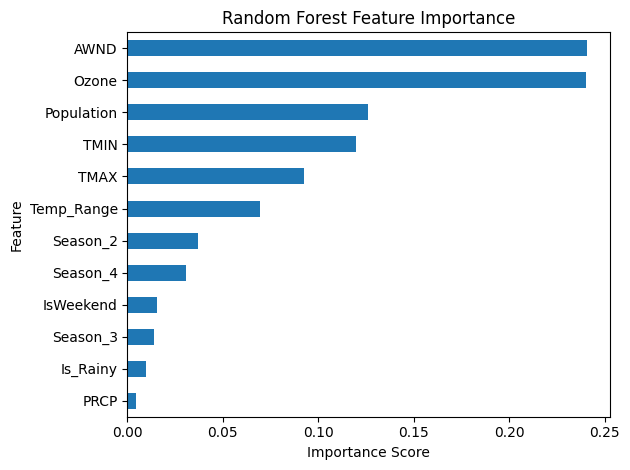

In [47]:
# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE PLOT
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

feature_importance_np.sort_values(
    by='Importance',
    ascending=True
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Interpretation of Feature Importance

The SHAP and Random Forest feature importance analyses showed that ozone concentration, wind speed (AWND), precipitation indicators, and temperature-related variables contributed meaningful predictive signal across the evaluated models.

Ozone emerged as one of the strongest independent predictors of unsafe AQI conditions. Wind-related variables likely captured pollutant dispersion effects, while precipitation indicators reflected atmospheric cleansing effects associated with rainfall. Seasonal variables also contributed important context related to wildfire activity and summer heat conditions in California.

## **Model Evaluation Criteria**

Because unsafe AQI observations represented only a small portion of the dataset, accuracy alone was not sufficient for evaluating model performance.

The evaluation focused primarily on:
- AUC, to measure overall class separation
- Recall for unsafe AQI days, to reduce missed high-risk events
- Precision, to limit excessive false positives

AUC was also used as the optimization metric during hyperparameter tuning because it performs well under class imbalance.

## **Random Forest Hyperparameter Tuning**

GridSearchCV and cross-validation were used to optimize Random Forest hyperparameters and improve generalization performance. Parameters including tree depth, number of estimators, minimum split size, and minimum leaf size were tested using AUC as the optimization metric. Although the tuned model maintained strong overall accuracy and AUC performance, it continued to struggle with identifying minority-class unsafe AQI observations due to severe class imbalance.

In [48]:
# ==========================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ==========================================

# Evaluate the tuned Random Forest model on the test set.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Define possible hyperparameter values to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV tests combinations of hyperparameters using cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation AUC:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation AUC: 0.9178981343093838


In [49]:
# Train final tuned Random Forest model using best parameters
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluate tuned model
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Tuned Random Forest AUC:", roc_auc_score(y_test, y_prob_best_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.9937032664305392
Tuned Random Forest AUC: 0.8145792177005136

Confusion Matrix:
[[2525    6]
 [  10    0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       0.00      0.00      0.00        10

    accuracy                           0.99      2541
   macro avg       0.50      0.50      0.50      2541
weighted avg       0.99      0.99      0.99      2541



## **Model Interpretation Using SHAP**

SHAP analysis was used to interpret how individual features contributed to Random Forest predictions.

This approach helps explain which variables increased or decreased the likelihood of predicting unsafe AQI conditions. The SHAP summary plot showed that ozone, population, temperature-related variables, and wind speed contributed most strongly to model predictions.

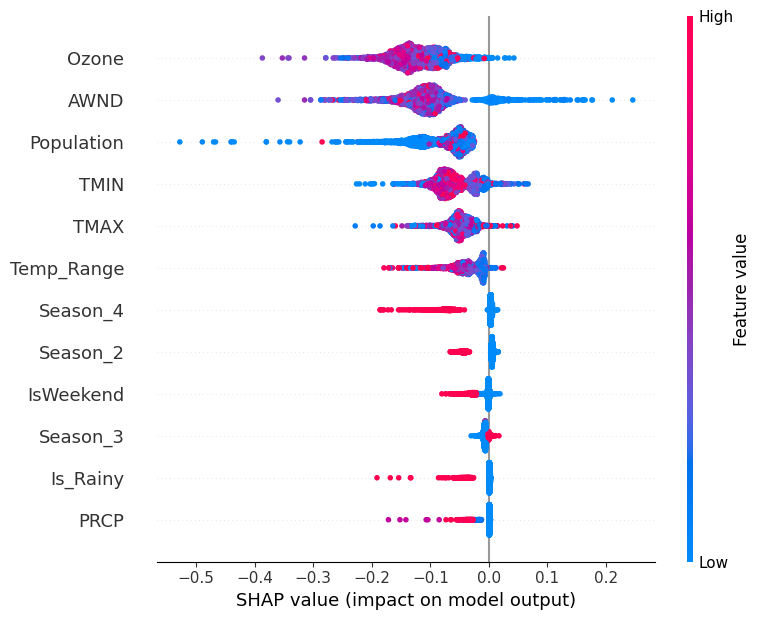

In [50]:
# ==========================================
# SHAP EXPLANATION FOR FINAL RANDOM FOREST MODEL
# ==========================================

# Use SHAP values to explain how each feature contributes to the final Random Forest predictions.

import shap

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer(X_test)

# Summary plot for class 1 = unsafe AQI
shap.summary_plot(shap_values[:, :, 1], X_test)

Key SHAP Insights:
- Higher ozone values generally increased the likelihood of unsafe AQI predictions.
- Population density contributed strongly to model output, suggesting urbanized areas may face greater AQI risk.
- Temperature and wind-related variables influenced prediction variability across observations.

Three models were evaluated to predict AQI category: Logistic Regression, Random Forest, and XGBoost.

Logistic Regression served as a strong baseline model, achieving perfect recall for unsafe AQI days but with lower precision, indicating a tendency toward false positives. Random Forest improved overall class separation and produced more stable probability estimates, although minority-class recall remained challenging under severe imbalance conditions.

The evaluated models demonstrated different tradeoffs between overall classification performance and minority-class recall under severe class imbalance conditions.

In [51]:
# Compare model performance using accuracy, AUC, precision, recall, and F1-score for the unsafe AQI class.

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'XGBoost',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test_np, y_pred_np),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test_np, y_prob_np),
        roc_auc_score(y_test, y_prob_best_rf)
    ],
    'Precision (Class 1)': [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0),
        precision_score(y_test_np, y_pred_np, zero_division=0),
        precision_score(y_test, y_pred_best_rf, zero_division=0)
    ],
    'Recall (Class 1)': [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0),
        recall_score(y_test_np, y_pred_np, zero_division=0),
        recall_score(y_test, y_pred_best_rf, zero_division=0)
    ],
    'F1-Score (Class 1)': [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0),
        f1_score(y_test_np, y_pred_np, zero_division=0),
        f1_score(y_test, y_pred_best_rf, zero_division=0)
    ]
})

comparison.set_index('Model').round(4)

,Accuracy,AUC,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
Model,,,,,
Logistic Regression,0.7651,0.8200,0.0116,0.7,0.0229
XGBoost,0.9965,0.9079,1.0000,0.1,0.1818
Random Forest,0.9957,0.7828,0.0000,0.0,0.0000
Tuned Random Forest,0.9937,0.8146,0.0000,0.0,0.0000


In [52]:
# Save Final Random Forest Model

import joblib

joblib.dump(rf_no_pm25, 'random_forest_model.sav')

['random_forest_model.sav']

In [53]:
# Save Final Logistic Regression Model

import joblib

joblib.dump(log_reg, 'logistic_regression_model.sav')

['logistic_regression_model.sav']

In [54]:
# Save Final XG Boost Model

import joblib

joblib.dump(xgb, 'xgboost_model.sav')

['xgboost_model.sav']

In [55]:
# Save Final Tuned Random Forest Model

import joblib

joblib.dump(best_rf, 'tuned_random_forest_model.sav')

['tuned_random_forest_model.sav']

## Streamlit App Deployment

The trained Random Forest model was exported and deployed as an interactive Streamlit web application. The app allows users to input real environmental and weather conditions for a California county and receive a real-time safe/unsafe AQI prediction with probability scores. The code below writes app.py to disk and downloads it alongside the saved model files for deployment to Streamlit Community Cloud.

In [59]:
import os

app_code = """
import streamlit as st
import numpy as np
import joblib
import os

st.set_page_config(page_title="California AQI Risk Predictor", page_icon="🌫️", layout="centered")

@st.cache_resource
def load_model():
    return joblib.load("random_forest_model.sav")

@st.cache_resource
def load_scaler():
    return joblib.load("scaler.sav")

model = load_model()
scaler = load_scaler()

st.title("🌫️ California AQI Risk Predictor")
st.caption("Random Forest · County-Level · Binary Classification")

ozone = st.number_input("Ozone (ppm)", min_value=0.000, max_value=0.200, value=0.040, step=0.001, format="%.3f")
population_raw = st.number_input("County Population", min_value=1000, max_value=10000000, value=500000, step=10000)
tmax = st.number_input("Max Temp (°F)", min_value=20, max_value=130, value=75)
tmin = st.number_input("Min Temp (°F)", min_value=0, max_value=110, value=55)
awnd = st.number_input("Wind Speed (mph)", min_value=0.0, max_value=60.0, value=7.0, step=0.5)
prcp = st.number_input("Precipitation (in)", min_value=0.00, max_value=10.00, value=0.00, step=0.01, format="%.2f")
season_label = st.selectbox("Season", ["Winter (Dec-Feb)", "Spring (Mar-May)", "Summer (Jun-Aug)", "Fall (Sep-Nov)"])
is_weekend = st.selectbox("Day Type", ["Weekday", "Weekend"])

season_map = {"Winter (Dec-Feb)": 1, "Spring (Mar-May)": 2, "Summer (Jun-Aug)": 3, "Fall (Sep-Nov)": 4}
season = season_map[season_label]
is_weekend_val = 1 if is_weekend == "Weekend" else 0
is_rainy = 1 if prcp > 0 else 0
temp_range = tmax - tmin
season_2 = 1 if season == 2 else 0
season_3 = 1 if season == 3 else 0
season_4 = 1 if season == 4 else 0

population_scaled = scaler.transform([[population_raw]])[0][0]

features = np.array([[ozone, is_weekend_val, population_scaled, prcp, tmax, tmin, awnd, temp_range, is_rainy, season_2, season_3, season_4]])

if st.button("Run Prediction", use_container_width=True):
    prediction = model.predict(features)[0]
    prob = model.predict_proba(features)[0]
    if prediction == 1:
        st.error(f" UNSAFE AQI PREDICTED — Risk probability: {prob[1]*100:.1f}%")
    else:
        st.success(f" SAFE AQI PREDICTED — Safe probability: {prob[0]*100:.1f}%")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully")
print("File size:", os.path.getsize("app.py"), "bytes")

app.py created successfully
File size: 2199 bytes


In [60]:
# Download app.py to your local machine
from google.colab import files
files.download("app.py")
files.download("random_forest_model.sav")
files.download("scaler.sav")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: scaler.sav

In [61]:
requirements = """streamlit>=1.32.0
scikit-learn>=1.3.0
numpy>=1.24.0
joblib>=1.3.0
pandas>=2.0.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully")
print(requirements)

files.download("requirements.txt")

requirements.txt created successfully
streamlit>=1.32.0
scikit-learn>=1.3.0
numpy>=1.24.0
joblib>=1.3.0
pandas>=2.0.0



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Requirements File

The requirements.txt file specifies the Python dependencies needed for the Streamlit app to run on Streamlit Community Cloud. This file must be included in the GitHub repository alongside app.py.

## Download Files for Deployment

Download app.py, the trained Random Forest model, and the fitted scaler to your local machine. These three files are uploaded together to the GitHub repository and referenced by Streamlit Community Cloud to run the live app.

## **Model Assumptions & Validation**

Logistic Regression assumes a linear relationship between predictors and the target outcome, while Random Forest and XGBoost are able to capture more complex non-linear relationships and feature interactions. Model performance was evaluated using a stratified train-test split to preserve class distribution. Cross-validation was additionally used during Random Forest hyperparameter tuning to improve model robustness and reduce overfitting risk.

## **Model Comparison & Key Insights**

Logistic Regression, Random Forest, and XGBoost were compared using accuracy, AUC, precision, recall, and F1-score. Logistic Regression produced the strongest recall for unsafe AQI observations but generated many false positives. XGBoost achieved the highest overall AUC and accuracy, while Random Forest models struggled to identify minority-class unsafe AQI events after PM2.5 removal.

Across the evaluated models, ozone concentration, weather conditions, seasonality, and demographic variables provided meaningful predictive signal, although severe class imbalance continued to limit minority-class AQI prediction performance.

## **Limitations**

One major limitation of this project is the severe class imbalance, since unsafe AQI days represented only a small percentage of observations. This made minority-class prediction more difficult and affected precision and recall values across models.

Another limitation is the strong dependence on PM2.5. Model performance declined substantially once PM2.5 was removed, suggesting that additional environmental or human activity variables may be necessary for more generalized AQI prediction.

Another limitation is that the weather dataset primarily reflected Los Angeles weather conditions and was merged across all California counties. Localized county-level weather variation may therefore not have been fully captured within the modeling framework.

Future improvements could include incorporating traffic patterns, wildfire data, industrial activity, or time-series forecasting approaches.

## **Conclusion and Recommendations**

This project explored whether unsafe AQI conditions in California could be predicted using environmental, weather, seasonal, and demographic variables. Multiple machine learning algorithms including Logistic Regression, Random Forest, and XGBoost were evaluated and compared using metrics such as accuracy, AUC, precision, recall, and F1-score.

Feature importance analysis and SHAP interpretation showed that ozone concentration, seasonal patterns, temperature-related variables, and precipitation indicators contributed meaningful predictive signal across the evaluated models. Ozone consistently emerged as one of the strongest independent predictors of unsafe AQI conditions, while weather variables such as temperature range, wind speed, and rainfall indicators helped capture the environmental conditions associated with pollution buildup and dispersion. Seasonal variables also played an important role, reflecting how wildfire activity, summer heat, and atmospheric conditions influence California air quality patterns throughout the year.

The analysis showed that environmental and meteorological variables such as ozone levels, temperature, precipitation, wind conditions, and seasonal patterns all contributed meaningful predictive signal for identifying unsafe AQI events. SHAP analysis and feature importance evaluation further demonstrated that weather-related variables and ozone consistently influenced model predictions, highlighting the importance of environmental context in air quality forecasting.

Integrating multiple external datasets strengthened the overall analytical framework by combining EPA air quality monitoring data with NOAA weather observations and U.S. Census demographic information. This multi-source approach captured a broader set of the environmental and population-level factors associated with poor air quality conditions across California counties.

Among the evaluated approaches, Logistic Regression achieved the strongest recall performance for unsafe AQI observations, while XGBoost achieved the highest overall AUC and accuracy. The tuned Random Forest model achieved an AUC of approximately 0.8146 after hyperparameter tuning, while Logistic Regression maintained the highest sensitivity for identifying minority-class unsafe AQI events. These findings demonstrate the tradeoff between overall predictive accuracy and minority-class detection under severe class imbalance conditions.

Overall, the project demonstrated how machine learning, environmental analytics, and explainable AI techniques can be combined to better understand air quality conditions and support future environmental monitoring and public health forecasting initiatives.

### Recommendations

- Future versions of this project should incorporate additional environmental variables such as wildfire activity, traffic density, industrial emissions, and humidity measurements to improve predictive performance.

- Time-series forecasting methods and deep learning approaches could also be explored to better capture temporal air quality patterns.

- Additional geographic expansion beyond California counties may improve generalizability and support broader environmental applications.

- More advanced imbalance-handling techniques such as SMOTE or cost-sensitive learning could further improve prediction performance for unsafe AQI observations.

- Future deployment of this system through Streamlit or cloud-based dashboards could support real-time environmental monitoring and public health awareness initiatives.

Overall, the analysis showed how machine learning and explainable AI techniques can support environmental forecasting and public health monitoring efforts.